# 05 · Detección de señas en video

Dado un video de entrada, detecta todas las ocurrencias de cada seña WH
y devuelve los **segundos de inicio y fin** de cada aparición.

**Flujo:**
1. Extraer landmarks frame a frame con MediaPipe
2. Deslizar una ventana de `N_FRAMES` sobre la secuencia completa
3. Predecir con el modelo SVM en cada posición de la ventana
4. Agrupar predicciones consecutivas de la misma seña en ocurrencias
5. Mostrar tabla de resultados y línea de tiempo

## Setup

In [16]:
import pickle
from pathlib import Path

import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display
import pandas as pd

# ── Parámetros ────────────────────────────────────────────────────────────────
MODEL_PATH   = Path('./models/svm_lsp.pkl')
VIDEO_PATH   = Path('./data/test_corto.mp4')  # ← cambia esto

STRIDE       = 5     # avanzar N frames entre cada ventana (sobre los frames muestreados)
UMBRAL_CONF  = 0.60  # confianza mínima para reportar QUE/QUIEN
UMBRAL_NADA  = 0.50  # si NADA supera esto, silenciar aunque haya ganador de otra clase
MIN_DURACION = 0.7   # segundos mínimos para reportar una ocurrencia

# Muestreo de FPS para la extracción de landmarks.
# El modelo normaliza a N_FRAMES con interpolación → bajar FPS no pierde precisión
# siempre que captures la dinámica del movimiento (señas ≈ 1-4 Hz → 15fps es suficiente).
# Ejemplo: video de 40s a 60fps → 2400 frames. A 20fps → 800 frames (3× más rápido).
TARGET_FPS   = 20    # fps efectivos a extraer (None = usar FPS original del video)

# ── Inicializar MediaPipe ─────────────────────────────────────────────────────
mp_hands = mp.solutions.hands
hands    = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    model_complexity=0,            # modelo liviano: ~30% más rápido, suficiente para señas
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
)

print(f'Video a analizar: {VIDEO_PATH}')
print(f'Modelo:           {MODEL_PATH}')
print(f'Umbral señas:     {UMBRAL_CONF:.0%}  |  Umbral NADA: {UMBRAL_NADA:.0%}')

Video a analizar: data/test_corto.mp4
Modelo:           models/svm_lsp.pkl
Umbral señas:     60%  |  Umbral NADA: 50%


I0000 00:00:1781588935.819790   44584 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1781588935.881314   46919 gl_context.cc:344] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 535.309.01), renderer: NVIDIA GeForce GTX 1050/PCIe/SSE2


## Sección 1 — Cargar modelo

In [17]:
with open(MODEL_PATH, 'rb') as f:
    bundle = pickle.load(f)

N_FRAMES = bundle['n_frames']
CLASES   = bundle['clases']

def limpiar_etiqueta(etiqueta: str) -> str:
    return etiqueta.rstrip('0123456789')

CLASES_LIMPIAS = [limpiar_etiqueta(c) for c in CLASES]

print(f'Modelo cargado')
print(f'  Clases:      {CLASES} → {CLASES_LIMPIAS}')
print(f'  CV accuracy: {bundle["cv_accuracy"]:.3f}')
print(f'  N frames:    {N_FRAMES}')

Modelo cargado
  Clases:      ['DONDE', 'NADA', 'POR_QUE', 'QUE1', 'QUIEN1'] → ['DONDE', 'NADA', 'POR_QUE', 'QUE', 'QUIEN']
  CV accuracy: 0.921
  N frames:    60


## Sección 2 — Extraer landmarks del video completo

In [18]:
def extraer_landmarks_video(
    video_path: Path,
    target_fps: float | None = None,
) -> tuple[np.ndarray, float]:
    """
    Extrae landmarks del video muestreando a target_fps (o al FPS original si es None).

    El modelo normaliza cada ventana a N_FRAMES con interpolación lineal, por lo que
    bajar el FPS de muestreo no afecta la precisión mientras se capture la dinámica
    del movimiento (señas LSP ≈ 1-4 Hz → 15 fps es suficiente por Nyquist).

    Devuelve:
      landmarks:   (T, 2, 21, 3)  — T frames muestreados
      fps_efectivo: float          — fps real al que se muestreó
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f'No se pudo abrir el video: {video_path}')

    fps_original = cap.get(cv2.CAP_PROP_FPS) or 30.0
    total_f      = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Cada cuántos frames originales tomamos uno
    step = max(1, round(fps_original / target_fps)) if target_fps else 1
    fps_efectivo = fps_original / step

    frames_a_procesar = (total_f + step - 1) // step
    print(f'Video original: {total_f} frames @ {fps_original:.1f} fps')
    print(f'Muestreo:       cada {step} frames → {frames_a_procesar} frames @ {fps_efectivo:.1f} fps efectivos')
    print(f'Aceleración:    ~{step:.1f}×')

    landmarks   = []
    frame_idx   = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        # Procesar solo los frames del paso
        if frame_idx % step == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            resultado = hands.process(frame_rgb)

            frame_lm = np.zeros((2, 21, 3), dtype=np.float32)
            if resultado.multi_hand_landmarks:
                for hand_lm, handedness in zip(
                    resultado.multi_hand_landmarks,
                    resultado.multi_handedness
                ):
                    idx = 0 if handedness.classification[0].label == 'Right' else 1
                    for j, lm in enumerate(hand_lm.landmark):
                        frame_lm[idx, j] = [lm.x, lm.y, lm.z]

            landmarks.append(frame_lm)

        frame_idx += 1

    cap.release()
    print(f'Extracción completa: {len(landmarks)} frames procesados')
    return np.array(landmarks, dtype=np.float32), fps_efectivo


landmarks_video, FPS = extraer_landmarks_video(VIDEO_PATH, target_fps=TARGET_FPS)
TOTAL_FRAMES = len(landmarks_video)
DURACION_SEG = TOTAL_FRAMES / FPS

print(f'\nVideo: {DURACION_SEG:.2f}s  |  {TOTAL_FRAMES} frames efectivos  |  {FPS:.1f} fps')

Video original: 2835 frames @ 59.9 fps
Muestreo:       cada 3 frames → 945 frames @ 20.0 fps efectivos
Aceleración:    ~3.0×
Extracción completa: 942 frames procesados

Video: 47.15s  |  942 frames efectivos  |  20.0 fps


## Sección 3 — Detección por ventana deslizante

In [19]:
def normalizar_longitud(secuencia: np.ndarray, n_frames: int) -> np.ndarray:
    T = len(secuencia)
    if T == n_frames:
        return secuencia
    indices  = np.linspace(0, T - 1, n_frames)
    resultado = np.zeros((n_frames, 2, 21, 3), dtype=np.float32)
    for i, idx in enumerate(indices):
        i0 = int(idx)
        i1 = min(i0 + 1, T - 1)
        alpha = idx - i0
        resultado[i] = secuencia[i0] * (1 - alpha) + secuencia[i1] * alpha
    return resultado


def predecir_ventana(probs: np.ndarray, clases: list[str]) -> tuple[str, float] | None:
    """
    Aplica la lógica de umbrales duales sobre el vector de probabilidades.

    Lógica:
      1. Si el modelo tiene NADA y su probabilidad >= UMBRAL_NADA → silencio
      2. Si la clase ganadora es NADA → silencio
      3. Si la confianza de la clase ganadora < UMBRAL_CONF → silencio
      4. Si pasa todo → devuelve (clase_limpia, confianza)
    """
    clases_list = list(clases)

    # Paso 1: NADA como silenciador explícito
    if 'NADA' in clases_list:
        prob_nada = probs[clases_list.index('NADA')]
        if prob_nada >= UMBRAL_NADA:
            return None

    idx_max   = probs.argmax()
    confianza = probs[idx_max]
    clase_raw = clases_list[idx_max]

    # Paso 2: si gana NADA de todas formas, silencio
    if limpiar_etiqueta(clase_raw) == 'NADA':
        return None

    # Paso 3: umbral de confianza para señas reales
    if confianza < UMBRAL_CONF:
        return None

    return limpiar_etiqueta(clase_raw), float(confianza)


def deslizar_ventana(landmarks: np.ndarray, fps: float) -> list[dict]:
    """
    Desliza una ventana de N_FRAMES sobre los landmarks y predice en cada posición.
    Aplica filtrado de NADA y umbral de confianza por ventana.
    Devuelve solo detecciones de señas reales (sin NADA).
    """
    T           = len(landmarks)
    detecciones = []
    silenciadas = 0
    clases_enc  = bundle['label_encoder'].classes_

    n_ventanas = len(range(0, T - N_FRAMES + 1, STRIDE))
    print(f'Ventanas a evaluar: {n_ventanas} (N_FRAMES={N_FRAMES}, stride={STRIDE})')

    for inicio in range(0, T - N_FRAMES + 1, STRIDE):
        fin     = inicio + N_FRAMES
        ventana = landmarks[inicio:fin]
        ventana = normalizar_longitud(ventana, N_FRAMES)
        vector  = ventana.flatten().reshape(1, -1)

        probs   = bundle['pipeline'].predict_proba(vector)[0]
        pred    = predecir_ventana(probs, clases_enc)

        if pred is None:
            silenciadas += 1
            continue

        clase, confianza = pred
        detecciones.append({
            'frame_inicio': inicio,
            'frame_fin':    fin,
            't_inicio':     inicio / fps,
            't_fin':        fin    / fps,
            'clase':        clase,
            'confianza':    confianza,
        })

    print(f'  Detecciones válidas:  {len(detecciones)}')
    print(f'  Silenciadas (NADA):   {silenciadas}')
    return detecciones


detecciones_raw = deslizar_ventana(landmarks_video, FPS)

Ventanas a evaluar: 177 (N_FRAMES=60, stride=5)
  Detecciones válidas:  7
  Silenciadas (NADA):   170


## Sección 4 — Agrupar detecciones solapadas en ocurrencias

In [20]:
def agrupar_ocurrencias(detecciones: list[dict], fps: float) -> list[dict]:
    """
    Fusiona ventanas solapadas de la misma clase en ocurrencias continuas.
    Una ocurrencia termina cuando:
      - cambia la clase, o
      - hay un gap de más de N_FRAMES frames sin detección de esa clase.
    Devuelve lista con t_inicio, t_fin, duracion, clase, confianza_media.
    """
    if not detecciones:
        return []

    ocurrencias = []
    actual = detecciones[0].copy()
    actual['confianzas'] = [actual['confianza']]

    gap_max_frames = N_FRAMES  # brecha máxima para considerar la misma ocurrencia

    for d in detecciones[1:]:
        misma_clase = d['clase'] == actual['clase']
        sin_gap     = d['frame_inicio'] <= actual['frame_fin'] + gap_max_frames

        if misma_clase and sin_gap:
            actual['frame_fin'] = max(actual['frame_fin'], d['frame_fin'])
            actual['t_fin']     = actual['frame_fin'] / fps
            actual['confianzas'].append(d['confianza'])
        else:
            duracion = actual['t_fin'] - actual['t_inicio']
            if duracion >= MIN_DURACION:
                ocurrencias.append({
                    'clase':           actual['clase'],
                    't_inicio':        round(actual['t_inicio'], 2),
                    't_fin':           round(actual['t_fin'], 2),
                    'duracion':        round(duracion, 2),
                    'confianza_media': round(float(np.mean(actual['confianzas'])), 3),
                })
            actual = d.copy()
            actual['confianzas'] = [d['confianza']]

    # última ocurrencia
    duracion = actual['t_fin'] - actual['t_inicio']
    if duracion >= MIN_DURACION:
        ocurrencias.append({
            'clase':           actual['clase'],
            't_inicio':        round(actual['t_inicio'], 2),
            't_fin':           round(actual['t_fin'], 2),
            'duracion':        round(duracion, 2),
            'confianza_media': round(float(np.mean(actual['confianzas'])), 3),
        })

    return ocurrencias


ocurrencias = agrupar_ocurrencias(detecciones_raw, FPS)

print(f'\nOcurrencias detectadas: {len(ocurrencias)}\n')
for i, oc in enumerate(ocurrencias, 1):
    print(f'  {i}. {oc["clase"]:<8}  '
          f'{oc["t_inicio"]:>6.2f}s → {oc["t_fin"]:>6.2f}s  '
          f'(duración: {oc["duracion"]:.2f}s, '
          f'confianza: {oc["confianza_media"]:.0%})')


Ocurrencias detectadas: 2

  1. QUE        19.27s →  22.52s  (duración: 3.25s, confianza: 76%)
  2. QUE        27.03s →  31.03s  (duración: 4.00s, confianza: 73%)


## Sección 5 — Resultados en tabla y línea de tiempo

In [21]:
# Tabla de resultados — solo señas reales (sin NADA)
señas_reales = [o for o in ocurrencias if o['clase'] != 'NADA']

if señas_reales:
    df = pd.DataFrame(señas_reales)
    df.index += 1
    df.columns = ['Seña', 'Inicio (s)', 'Fin (s)', 'Duración (s)', 'Confianza media']
    print(f'Ocurrencias de señas detectadas: {len(señas_reales)}\n')
    display(df.style
              .format({'Inicio (s)': '{:.2f}', 'Fin (s)': '{:.2f}',
                       'Duración (s)': '{:.2f}', 'Confianza media': '{:.0%}'})
              .background_gradient(subset=['Confianza media'], cmap='Greens')
    )
else:
    print('No se detectaron señas con los parámetros actuales.')
    print(f'  Prueba bajando UMBRAL_CONF (actual: {UMBRAL_CONF}) o UMBRAL_NADA (actual: {UMBRAL_NADA})')

Ocurrencias de señas detectadas: 2



,Seña,Inicio (s),Fin (s),Duración (s),Confianza media
1,QUE,19.27,22.52,3.25,76%
2,QUE,27.03,31.03,4.00,73%


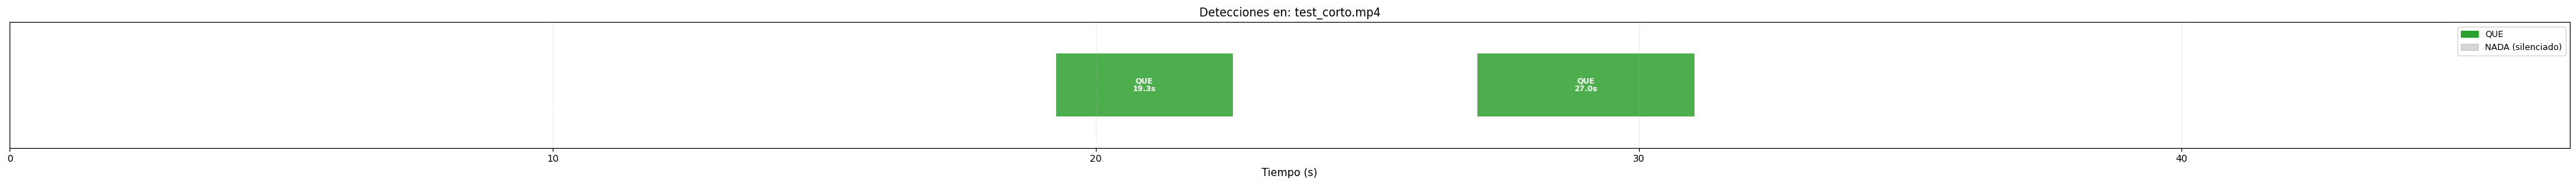

Gráfico guardado en: test_corto_detecciones.png


In [22]:
# Línea de tiempo — señas en barras coloreadas, NADA como fondo gris
CLASES_SEÑAS = [limpiar_etiqueta(c) for c in CLASES if limpiar_etiqueta(c) != 'NADA']
COLORES_SEÑAS = {c: plt.cm.tab10(i) for i, c in enumerate(CLASES_SEÑAS)}

fig, ax = plt.subplots(figsize=(max(10, DURACION_SEG * 0.8), 2.8))

ax.set_xlim(0, DURACION_SEG)
ax.set_ylim(0, 1)
ax.set_xlabel('Tiempo (s)', fontsize=11)
ax.set_title(f'Detecciones en: {VIDEO_PATH.name}', fontsize=12)
ax.set_yticks([])
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Zonas NADA como fondo gris (contexto: aquí el modelo estaba silenciado)
nada_ocs = [o for o in ocurrencias if o['clase'] == 'NADA']
for oc in nada_ocs:
    ax.axvspan(oc['t_inicio'], oc['t_fin'], alpha=0.15, color='gray')

# Señas reales como barras
for oc in señas_reales:
    color = COLORES_SEÑAS.get(oc['clase'], 'steelblue')
    ax.barh(
        y=0.5, left=oc['t_inicio'],
        width=oc['t_fin'] - oc['t_inicio'],
        height=0.5, color=color, alpha=0.85, align='center'
    )
    ax.text(
        (oc['t_inicio'] + oc['t_fin']) / 2, 0.5,
        f"{oc['clase']}\n{oc['t_inicio']:.1f}s",
        ha='center', va='center', fontsize=8, color='white', fontweight='bold'
    )

# Leyenda
leyenda = [
    mpatches.Patch(color=COLORES_SEÑAS[c], label=c)
    for c in COLORES_SEÑAS if any(o['clase'] == c for o in señas_reales)
]
leyenda.append(mpatches.Patch(color='gray', alpha=0.3, label='NADA (silenciado)'))
ax.legend(handles=leyenda, loc='upper right', fontsize=9)

plt.tight_layout()
output_img = VIDEO_PATH.stem + '_detecciones.png'
plt.savefig(output_img, dpi=120, bbox_inches='tight')
plt.show()
print(f'Gráfico guardado en: {output_img}')

## Sección 6 — Exportar resultados a JSON/CSV

In [23]:
import json

resultado_final = {
    'video':      str(VIDEO_PATH),
    'duracion_s': round(DURACION_SEG, 2),
    'fps':        round(FPS, 2),
    'modelo':     str(MODEL_PATH),
    'parametros': {
        'umbral_confianza': UMBRAL_CONF,
        'umbral_nada':      UMBRAL_NADA,
        'min_duracion_s':   MIN_DURACION,
        'stride_frames':    STRIDE,
        'n_frames_ventana': N_FRAMES,
        'target_fps':       TARGET_FPS,
        'fps_efectivo':     round(FPS, 2),
    },
    'señas': señas_reales,  # solo QUE/QUIEN — lo que interesa para la app
}

json_path = Path(VIDEO_PATH.stem + '_detecciones.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(resultado_final, f, ensure_ascii=False, indent=2)

print(f'Resultados guardados en: {json_path}')
print()
print(json.dumps(resultado_final, ensure_ascii=False, indent=2))
print(f'\nResumen: {len(señas_reales)} señas detectadas en {DURACION_SEG:.1f}s de video')

Resultados guardados en: test_corto_detecciones.json

{
  "video": "data/test_corto.mp4",
  "duracion_s": 47.15,
  "fps": 19.98,
  "modelo": "models/svm_lsp.pkl",
  "parametros": {
    "umbral_confianza": 0.6,
    "umbral_nada": 0.5,
    "min_duracion_s": 0.7,
    "stride_frames": 5,
    "n_frames_ventana": 60,
    "target_fps": 20,
    "fps_efectivo": 19.98
  },
  "señas": [
    {
      "clase": "QUE",
      "t_inicio": 19.27,
      "t_fin": 22.52,
      "duracion": 3.25,
      "confianza_media": 0.76
    },
    {
      "clase": "QUE",
      "t_inicio": 27.03,
      "t_fin": 31.03,
      "duracion": 4.0,
      "confianza_media": 0.734
    }
  ]
}

Resumen: 2 señas detectadas en 47.1s de video


---
## ¿Cómo usar con otro video?

Solo cambia `VIDEO_PATH` en la celda de Setup y re-ejecuta todo:

```python
VIDEO_PATH = Path('./data/clips/QUE1/que1_001.mp4')
```

**Parámetros a ajustar:**

| Parámetro | Qué controla | Ajuste típico |
|---|---|---|
| `UMBRAL_CONF` ↑ | Más estricto para reportar QUE/QUIEN | Subir si hay falsos positivos |
| `UMBRAL_CONF` ↓ | Más permisivo | Bajar si no detecta señas reales |
| `UMBRAL_NADA` ↑ | NADA silencia menos | Si silencia demasiado |
| `UMBRAL_NADA` ↓ | NADA silencia más | Si hay demasiados falsos positivos |
| `STRIDE` ↓ | Más granular (más lento) | Para mayor precisión temporal |
| `MIN_DURACION` ↓ | Reporta ocurrencias más cortas | Para señas rápidas |

**Lógica de decisión por ventana:**
```
probs → [QUE: p1,  QUIEN: p2,  NADA: p3]
         │
         ├─ p3 >= UMBRAL_NADA (0.50) → silencio
         │
         └─ clase_ganadora != NADA AND confianza >= UMBRAL_CONF (0.80) → reportar
```